<a href="https://colab.research.google.com/github/ridahafeez786/AI_Bootcamp_Lab-work/blob/main/streamvibe_case_study_Rida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🎬 Capstone Case Study — StreamVibe Subscriber Churn Prediction

**AI & Machine Learning Bootcamp — Capstone Activity**

---

## 📋 Case Study Brief

**StreamVibe** is a video streaming subscription service. Like every
subscription business, StreamVibe loses a percentage of its customers
("**churn**") every month. The retention team wants to know, **in
advance**, which customers are likely to cancel — so they can step in
with a targeted discount, a re-engagement email, or a personal check-in
call before that customer leaves for good.

**Your task:** build a complete machine learning pipeline, from raw data
to a business recommendation, that predicts whether a customer will
churn (`churned` = "Yes" or "No"). You will implement and compare
**three different classification models**:

1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Random Forest**

---

### ✅ What you need to do

This notebook is a **guided pipeline**, not a blank page. Every section
has:
- 📝 **Markdown instructions** explaining what the step is and why it matters
- 💻 A code cell marked **`# TODO`** for you to fill in
- 💡 **Hints** to point you toward the right method/parameter, without
  giving away the exact line of code

Cells that say **`# --- GIVEN: do not need to modify ---`** are already
complete (setup code, helper functions, or checkpoints) — you don't need
to edit those, but do read them, since later TODOs build on them.

### 🎯 Deliverables (what you'll produce by the end)

- A cleaned, fully encoded dataset ready for modeling
- Three trained models: Logistic Regression, KNN, Random Forest
- An evaluation of all three using a consistent set of metrics
- A short written business recommendation: which model would you
  actually deploy at StreamVibe, and why?

### 📊 Grading checkpoint hints

Most TODO sections are followed by a "checkpoint" print statement you can
run to sanity-check your work (e.g., expected shape, expected number of
columns). These are guides, not guarantees — use your judgment too!

Good luck — treat this like a real (small) data science project. 🚀



## 1. Setup

This cell is already complete. It imports everything you'll need for the
whole notebook, and fixes a random seed so your results are reproducible.


In [1]:

# --- GIVEN: do not need to modify ---

# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete.")


Setup complete.



### A reusable evaluation helper (given)

To make it easy to fairly compare all three of your models later, here's
a helper function that computes a standard set of metrics and plots a
confusion matrix. **You'll call this function after training each
model** — you don't need to write your own metric code from scratch.


In [2]:

# --- GIVEN: do not need to modify ---

results_summary = []  # every call below appends one row here for the final comparison table

def evaluate_classifier(model, X_test, y_test, model_name, plot=True):
    # Compute standard classification metrics and (optionally) plot a confusion matrix.
    # Appends a results row to the global `results_summary` list for later comparison.
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]  # probability of the positive class ("Yes")

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)

    print(f"===== {model_name} =====")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"ROC-AUC:   {auc:.3f}")
    print()
    print(classification_report(y_test, preds, target_names=["No churn", "Churned"]))

    if plot:
        cm = confusion_matrix(y_test, preds)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn", "Churned"])
        fig, ax = plt.subplots(figsize=(5, 5))
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(f"{model_name} -- Confusion Matrix")
        plt.show()

    results_summary.append({
        "model": model_name, "accuracy": acc, "precision": prec,
        "recall": rec, "f1_score": f1, "roc_auc": auc
    })
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1_score": f1, "roc_auc": auc, "probabilities": proba}

print("evaluate_classifier() is ready to use.")


evaluate_classifier() is ready to use.



## 2. Load the Dataset

`streamvibe_churn.csv` was generated by `generate_dataset.py` (also
provided) and represents 4,000 StreamVibe subscribers, with a mix of
numeric, categorical, boolean, and ordinal features, plus the target
column `churned` ("Yes"/"No").

### 📝 Your task
- Load the CSV into a variable called `df`
- Display the first few rows
- Display the shape (rows, columns)
- Display the column data types


In [5]:
from google.colab import files
uploaded = files.upload()

Saving streamvibe_churn.csv to streamvibe_churn (2).csv


In [6]:

# TODO:
# 1. Load "streamvibe_churn.csv" into a variable called `df`
#    Hint: pd.read_csv(...)
# 2. Print df.shape
# 3. Display df.head()

df = pd.read_csv("streamvibe_churn.csv")

# your code here
print(df.shape)
df.head()

(4000, 21)


,customer_id,age,customer_tenure_months,avg_watch_hours_per_week,avg_session_length_min,days_since_last_login,number_of_devices,number_of_support_tickets,monthly_price,discount_percent,...,device_type_primary,payment_method,auto_renew_enabled,uses_offline_downloads,shared_account,watched_trending_content,engagement_level,satisfaction_rating,churn_score_hidden,churned
0,SV500555,31,6.5,2.8,63.3,5.1,3,0.0,12.99,30,...,Laptop,Debit Card,True,True,True,True,Low,High,-17.29,No
1,SV503491,23,15.3,2.0,38.1,34.7,5,0.0,8.99,0,...,Laptop,PayPal,True,True,True,False,Medium,High,6.85,Yes
2,SV500527,35,2.3,3.2,37.6,6.1,4,2.0,8.99,0,...,Tablet,Credit Card,True,True,False,True,Medium,NaN,3.61,No
3,SV503925,44,15.9,5.4,30.9,18.5,1,4.0,8.99,20,...,Tablet,PayPal,True,False,True,False,Medium,Medium,-0.39,No
4,SV502989,49,7.4,19.2,73.6,7.2,2,0.0,8.99,20,...,Laptop,Credit Card,False,False,True,False,High,High,-9.06,No


In [7]:

# --- GIVEN: checkpoint ---
assert df is not None, "df is still None -- did you load the CSV?"
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
print("Expected: roughly 4000 rows and 21 columns.")
df.dtypes


Loaded 4000 rows and 21 columns.
Expected: roughly 4000 rows and 21 columns.


,0
customer_id,object
age,int64
customer_tenure_months,float64
avg_watch_hours_per_week,float64
avg_session_length_min,float64
days_since_last_login,float64
number_of_devices,int64
number_of_support_tickets,float64
monthly_price,float64
discount_percent,int64



### ⚠️ Important: two columns you must NOT use as model features

- `customer_id` — just a unique identifier, not a real feature
- `churn_score_hidden` — an internal reference number used to *build* this
  synthetic dataset. Leaving it in your features would be **data leakage**
  (it's essentially a giveaway of the answer!) and will make your models
  look impossibly good. Drop both before modeling — you'll do this in
  Section 4.



## 3. Exploratory Data Analysis (EDA)

### 📝 Your task

Complete each of the following mini-tasks in its own code cell:

1. Check for missing values (count per column)
2. Plot the target class balance (`churned`) as a bar chart
3. Plot histograms of the numeric features
4. Plot boxplots of the numeric features (to spot outliers)
5. Plot a correlation heatmap of the numeric features
6. Plot the distribution of at least 2 categorical features

💡 **Hint:** the numeric columns are: `age`, `customer_tenure_months`,
`avg_watch_hours_per_week`, `avg_session_length_min`,
`days_since_last_login`, `number_of_devices`, `number_of_support_tickets`,
`monthly_price`, `discount_percent`. It may help to store this list in a
variable now, e.g. `numeric_cols = [...]`, so you can reuse it in later
sections too.


In [10]:

# TODO 1: Check for missing values per column
# Hint: df.isna().sum()

numeric_cols = [
    "age", "customer_tenure_months", "avg_watch_hours_per_week", "avg_session_length_min",
    "days_since_last_login", "number_of_devices", "number_of_support_tickets",
    "monthly_price", "discount_percent"
]

# your code here
df.isna().sum()
clean_df = df.drop(
    columns=["customer_id", "churn_score_hidden"]
)
clean_df.shape

(4000, 19)

Churn class percentages:
churned
No     70.78
Yes    29.22
Name: proportion, dtype: float64


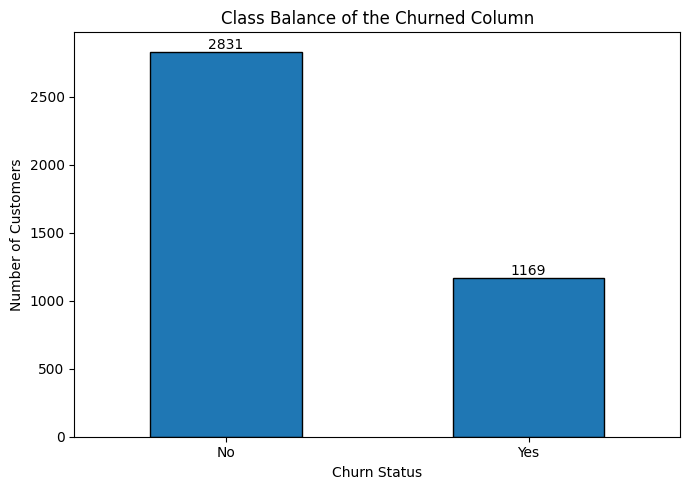

In [11]:

# TODO 2: Plot the class balance of the `churned` column as a bar chart
# Hint: df["churned"].value_counts().plot(kind="bar")
# Also print the normalized (percentage) value counts

# your code here

# Count how many customers belong to each churn class.
churn_counts = df["churned"].value_counts()

# Print the percentage of customers in each class.
# normalize=True returns proportions, and multiplying by 100 converts
# those proportions into percentages.
churn_percentages = (
    df["churned"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Churn class percentages:")
print(churn_percentages)

# Plot the number of customers in each churn class.
ax = churn_counts.plot(
    kind="bar",
    figsize=(7, 5),
    edgecolor="black"
)

# Add the count above each bar so the chart is easier to read.
for container in ax.containers:
    ax.bar_label(container)

plt.title("Class Balance of the Churned Column")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

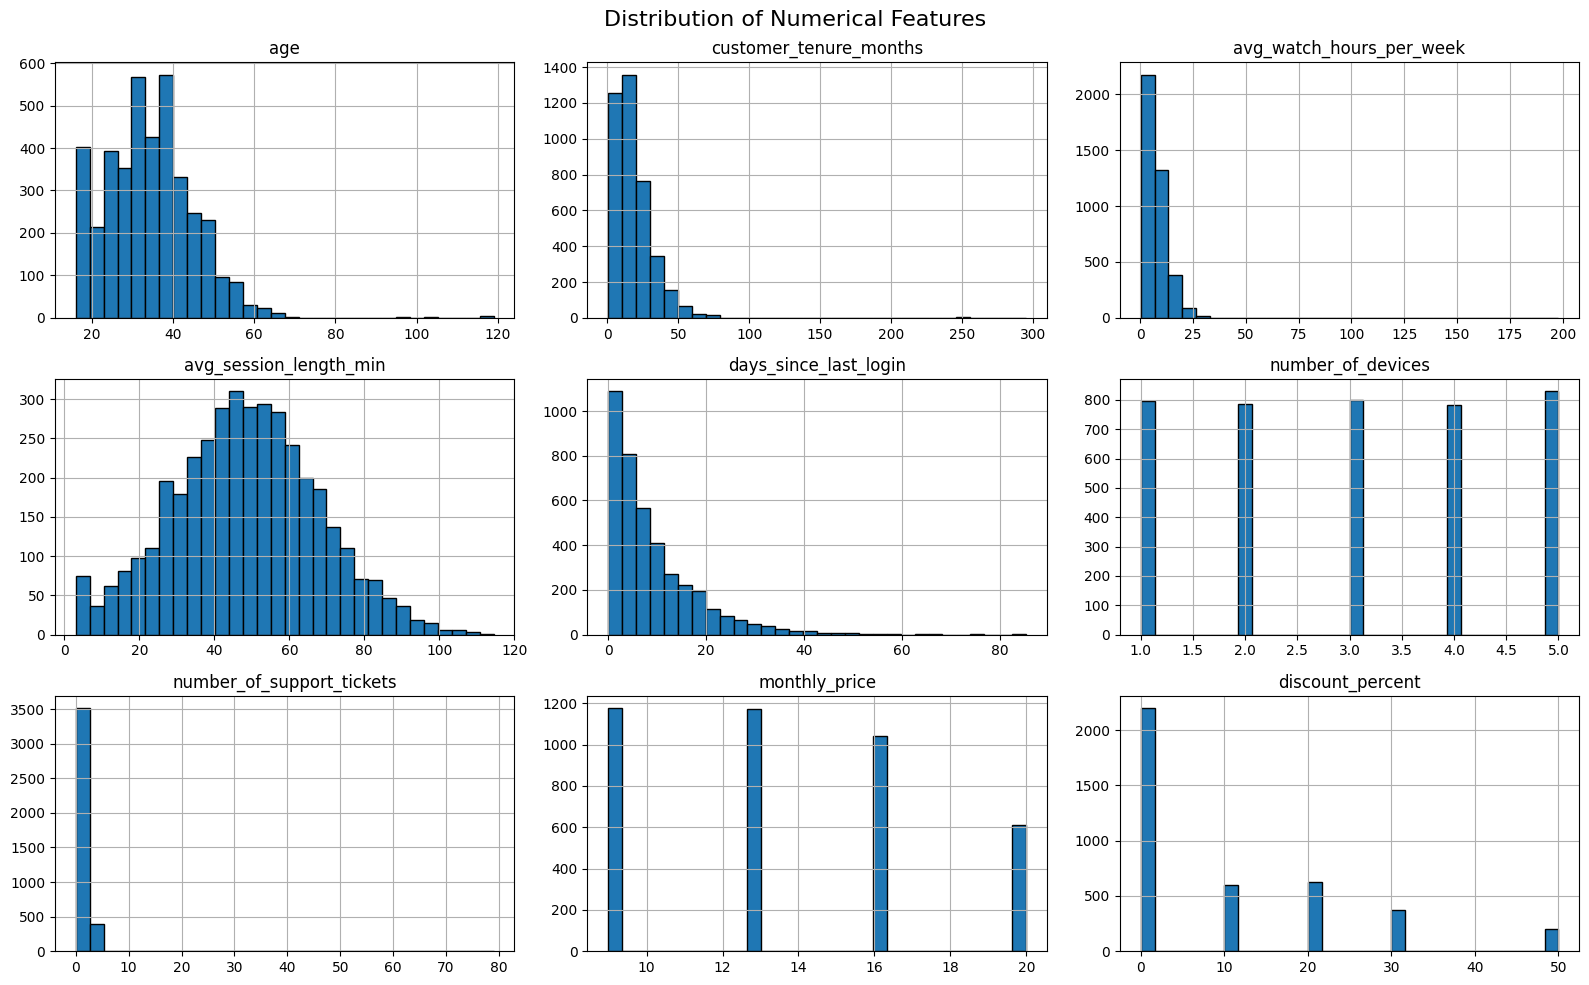

In [12]:

# TODO 3: Plot histograms of every column in `numeric_cols`
# Hint: df[numeric_cols].hist(figsize=(16, 10), bins=30)

# your code here
df[numeric_cols].hist(
    figsize=(16, 10),
    bins=30,
    edgecolor="black"
)

# Add a main title above all histograms.
plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

# Adjust spacing so titles and labels do not overlap.
plt.tight_layout()

# Display all histograms.
plt.show()

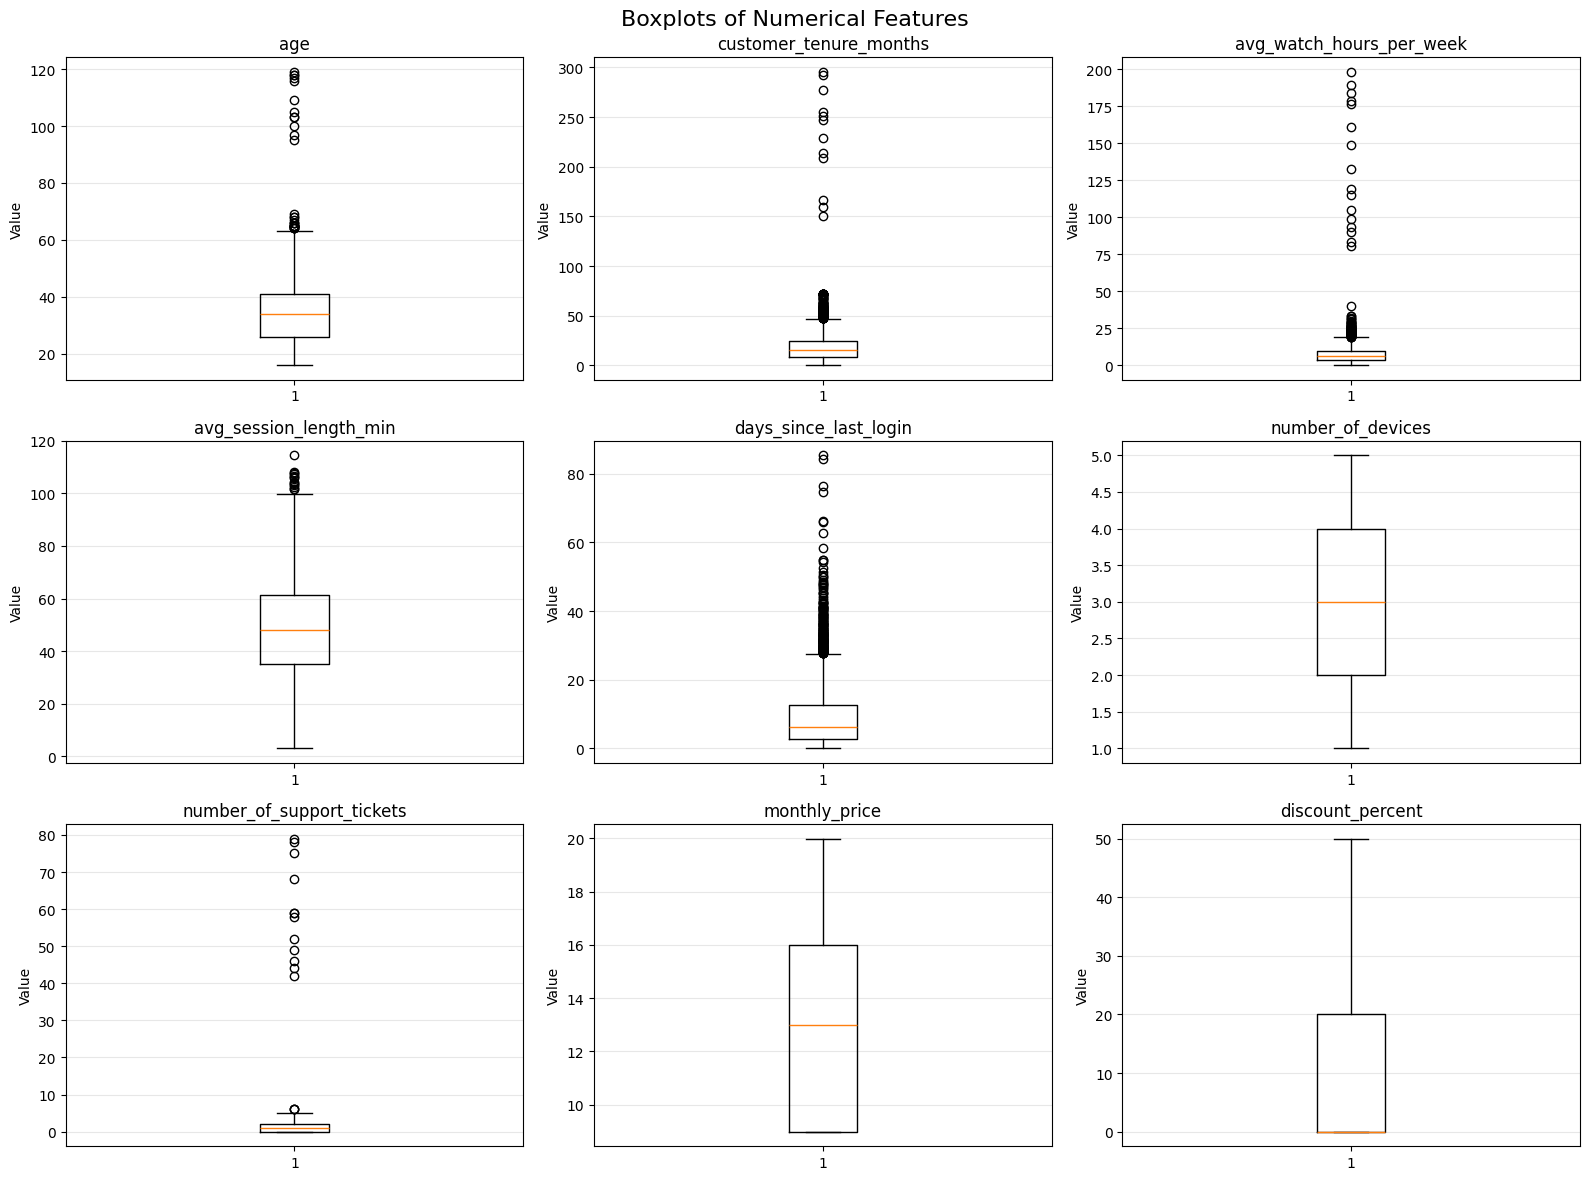

In [13]:

# TODO 4: Plot a boxplot for each numeric column so you can visually spot outliers
# Hint: loop over numeric_cols, use axes[i].boxplot(df[col].dropna())

# your code here

import math
import matplotlib.pyplot as plt

# Number of plots per row
plots_per_row = 3

# Calculate the number of rows required
number_of_rows = math.ceil(
    len(numeric_cols) / plots_per_row
)

# Create a grid of plots
fig, axes = plt.subplots(
    number_of_rows,
    plots_per_row,
    figsize=(16, number_of_rows * 4)
)

# Convert axes into a one-dimensional array so that
# axes[i] can be used inside the loop.
axes = axes.flatten()

# Create one boxplot for each numerical column.
for i, col in enumerate(numeric_cols):

    # dropna() removes missing values before plotting.
    axes[i].boxplot(
        df[col].dropna()
    )

    axes[i].set_title(col)
    axes[i].set_ylabel("Value")
    axes[i].grid(
        axis="y",
        alpha=0.3
    )

# Hide any unused plot spaces.
for i in range(
    len(numeric_cols),
    len(axes)
):
    axes[i].set_visible(False)

# Add a main title and fix spacing.
plt.suptitle(
    "Boxplots of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

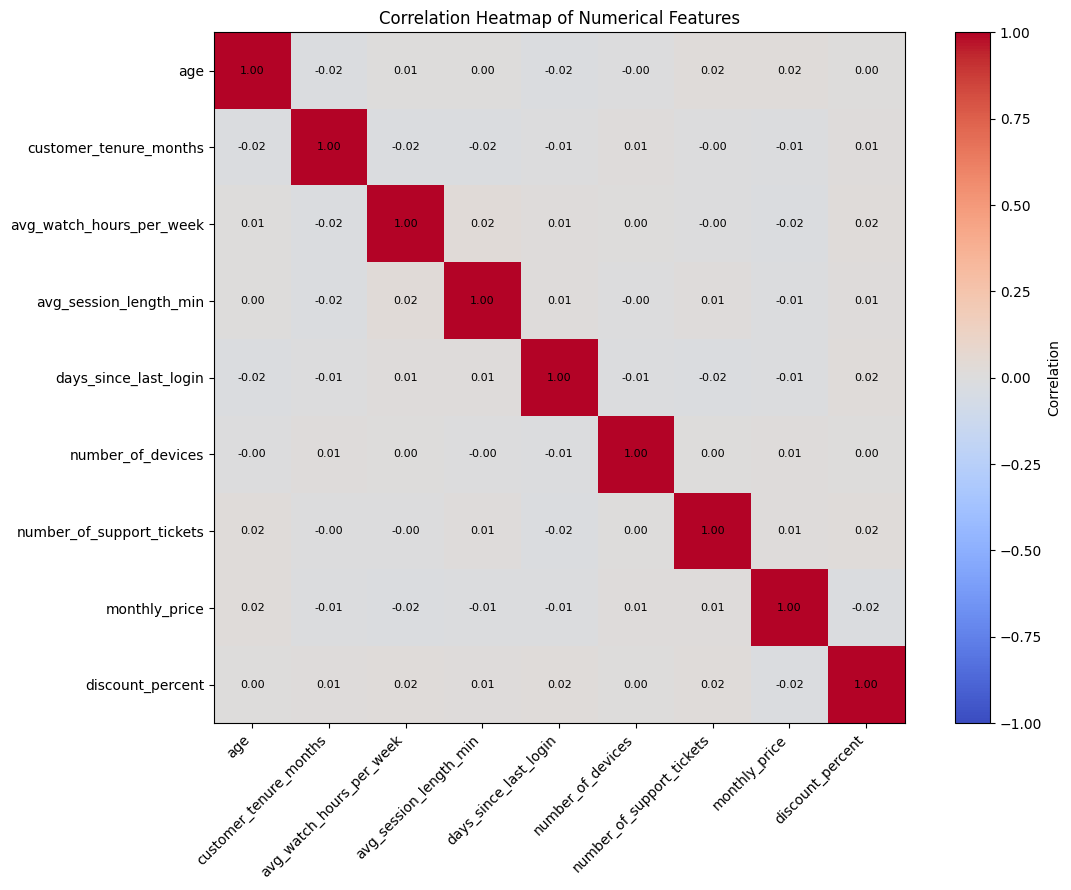

In [14]:

# TODO 5: Plot a correlation heatmap of `numeric_cols`
# Hint: df[numeric_cols].corr(), then ax.imshow(...)

# your code here

# Calculate the correlation between every pair of numerical columns.
# Correlation values range from:
# -1 = strong negative relationship
#  0 = no linear relationship
# +1 = strong positive relationship
correlation_matrix = df[numeric_cols].corr()

# Create the figure and plotting area.
fig, ax = plt.subplots(figsize=(12, 9))

# Display the correlation matrix as a heatmap.
heatmap = ax.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

# Place column names along both axes.
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))

ax.set_xticklabels(
    numeric_cols,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(numeric_cols)

# Write the correlation value inside each square.
for row in range(len(numeric_cols)):
    for col in range(len(numeric_cols)):
        ax.text(
            col,
            row,
            f"{correlation_matrix.iloc[row, col]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

# Add a color scale showing the meaning of the colors.
fig.colorbar(
    heatmap,
    ax=ax,
    label="Correlation"
)

ax.set_title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

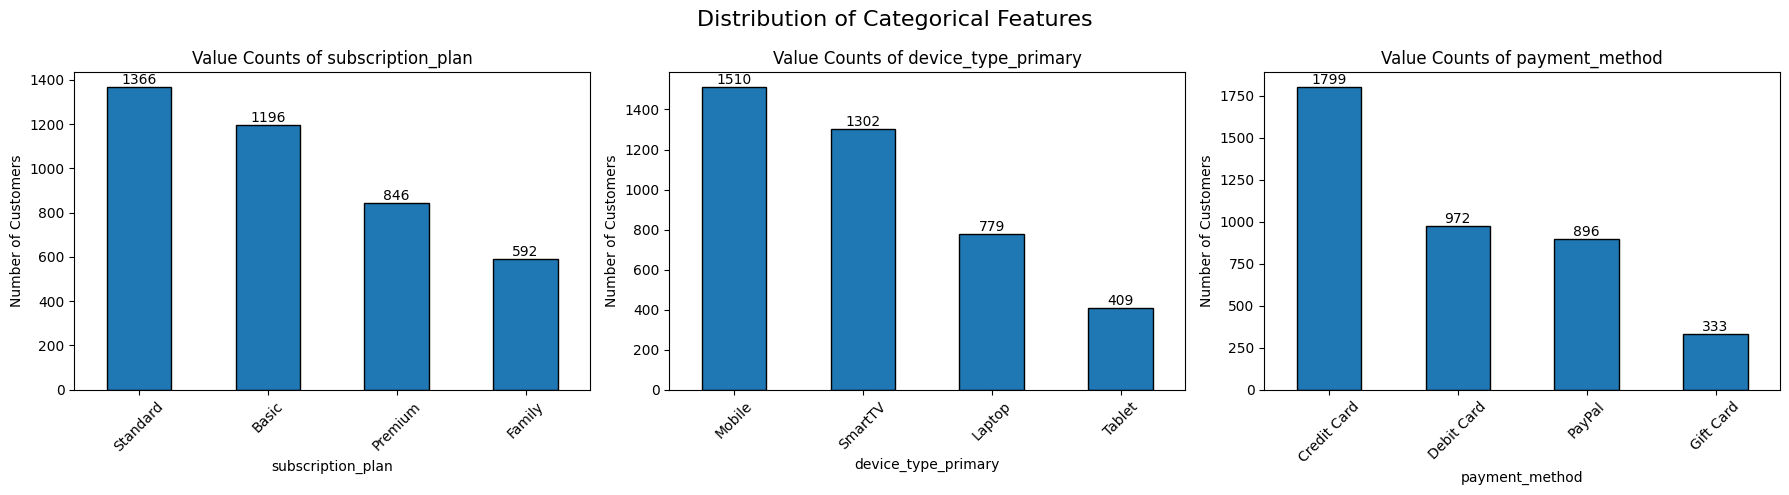

In [15]:

# TODO 6: Plot the value counts of at least 2 categorical columns
# (subscription_plan, device_type_primary, payment_method are good choices)
# Hint: df[col].value_counts().plot(kind="bar")

# your code here
# Select the categorical columns that we want to examine.
categorical_cols = [
    "subscription_plan",
    "device_type_primary",
    "payment_method"
]

# Create one subplot for each categorical column.
fig, axes = plt.subplots(
    1,
    len(categorical_cols),
    figsize=(18, 5)
)

# Plot the value counts of every selected categorical column.
for i, col in enumerate(categorical_cols):

    # Count how many customers belong to each category.
    category_counts = df[col].value_counts()

    # Create a bar chart.
    category_counts.plot(
        kind="bar",
        ax=axes[i],
        edgecolor="black"
    )

    # Add the count above each bar.
    for container in axes[i].containers:
        axes[i].bar_label(container)

    axes[i].set_title(f"Value Counts of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of Customers")
    axes[i].tick_params(
        axis="x",
        rotation=45
    )

# Add a main title and adjust spacing.
plt.suptitle(
    "Distribution of Categorical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()


### 🤔 Before moving on, think about:
- Which numeric features look like they might separate churners from
  non-churners (different-looking distributions)? You'll be able to check
  your intuition later using feature importance.
- Which columns clearly contain outliers? What does that outlier look
  like — is it a plausible extreme value, or an impossible one?



## 4. Data Cleaning

### 📝 Your task

1. Drop `customer_id` and `churn_score_hidden` (remember: leakage!) from a
   working copy of the dataframe — call it `clean_df`.
2. Handle the missing values you found in Section 3 (in
   `avg_session_length_min`, `number_of_support_tickets`, and
   `satisfaction_rating`). Numeric columns: fill with the **median**.
   The categorical/ordinal column (`satisfaction_rating`): fill with the
   **mode** (most frequent value).
3. Handle the outliers you spotted in Section 3's boxplots. You don't have
   to remove rows — **capping** (clipping) impossible values to a sensible
   maximum/minimum is usually a better choice here than deleting real
   customer rows. At minimum, address:
   - `age` (impossible values above ~90)
   - `avg_watch_hours_per_week` (impossible values above ~50 hours/week)
   - `customer_tenure_months` (impossible values above ~80 months)
   - `number_of_support_tickets` (impossible values above ~12)

💡 **Hint:** `Series.clip(upper=...)` is the tool for capping.


In [16]:

# TODO:
# 1. Create `clean_df` = df with "customer_id" and "churn_score_hidden" dropped
# 2. Fill missing numeric values with the median; fill satisfaction_rating with the mode
#    Hint: series.mode()[0] gives the most frequent value
# 3. Cap the outliers listed above using .clip(upper=...)

#clean_df = None  # <-- replace this

# your code here
clean_df = df.drop(
    columns=[
        "customer_id",
        "churn_score_hidden"
    ]
).copy()


# ------------------------------------------------------------
# 2. Fill missing values
# ------------------------------------------------------------

# Find all numerical columns in clean_df.
numeric_columns = clean_df.select_dtypes(
    include="number"
).columns

# Fill missing values in every numerical column with
# that column's median.
for col in numeric_columns:
    clean_df[col] = clean_df[col].fillna(
        clean_df[col].median()
    )

# Fill missing satisfaction ratings with the most
# frequently occurring rating.
clean_df["satisfaction_rating"] = (
    clean_df["satisfaction_rating"]
    .fillna(
        clean_df["satisfaction_rating"].mode()[0]
    )
)


# ------------------------------------------------------------
# 3. Cap the identified outliers
# ------------------------------------------------------------

clean_df["age"] = clean_df["age"].clip(
    upper=90
)

clean_df["avg_watch_hours_per_week"] = (
    clean_df["avg_watch_hours_per_week"]
    .clip(upper=50)
)

clean_df["customer_tenure_months"] = (
    clean_df["customer_tenure_months"]
    .clip(upper=80)
)

clean_df["number_of_support_tickets"] = (
    clean_df["number_of_support_tickets"]
    .clip(upper=12)
)


# ------------------------------------------------------------
# Verify the cleaning
# ------------------------------------------------------------

print("Remaining missing values:")
print(clean_df.isnull().sum())

print("\nMaximum values after capping:")
print(
    clean_df[
        [
            "age",
            "avg_watch_hours_per_week",
            "customer_tenure_months",
            "number_of_support_tickets"
        ]
    ].max()
)

print("\nShape of cleaned dataset:")
print(clean_df.shape)

clean_df.head()

Remaining missing values:
age                          0
customer_tenure_months       0
avg_watch_hours_per_week     0
avg_session_length_min       0
days_since_last_login        0
number_of_devices            0
number_of_support_tickets    0
monthly_price                0
discount_percent             0
subscription_plan            0
device_type_primary          0
payment_method               0
auto_renew_enabled           0
uses_offline_downloads       0
shared_account               0
watched_trending_content     0
engagement_level             0
satisfaction_rating          0
churned                      0
dtype: int64

Maximum values after capping:
age                          90.0
avg_watch_hours_per_week     50.0
customer_tenure_months       80.0
number_of_support_tickets    12.0
dtype: float64

Shape of cleaned dataset:
(4000, 19)


,age,customer_tenure_months,avg_watch_hours_per_week,avg_session_length_min,days_since_last_login,number_of_devices,number_of_support_tickets,monthly_price,discount_percent,subscription_plan,device_type_primary,payment_method,auto_renew_enabled,uses_offline_downloads,shared_account,watched_trending_content,engagement_level,satisfaction_rating,churned
0,31,6.5,2.8,63.3,5.1,3,0.0,12.99,30,Standard,Laptop,Debit Card,True,True,True,True,Low,High,No
1,23,15.3,2.0,38.1,34.7,5,0.0,8.99,0,Basic,Laptop,PayPal,True,True,True,False,Medium,High,Yes
2,35,2.3,3.2,37.6,6.1,4,2.0,8.99,0,Standard,Tablet,Credit Card,True,True,False,True,Medium,High,No
3,44,15.9,5.4,30.9,18.5,1,4.0,8.99,20,Standard,Tablet,PayPal,True,False,True,False,Medium,Medium,No
4,49,7.4,19.2,73.6,7.2,2,0.0,8.99,20,Basic,Laptop,Credit Card,False,False,True,False,High,High,No


In [17]:

# --- GIVEN: checkpoint ---
assert clean_df is not None, "clean_df is still None"
assert "customer_id" not in clean_df.columns and "churn_score_hidden" not in clean_df.columns, \
    "Make sure you dropped customer_id and churn_score_hidden!"
print("Remaining missing values:", clean_df.isna().sum().sum(), "(expected: 0)")
print("Max age:", clean_df["age"].max(), "(expected: <= 90)")


Remaining missing values: 0 (expected: 0)
Max age: 90 (expected: <= 90)



## 5. Feature Encoding

Models need numbers, not text. Recall from Session 4:
- **One-hot encode** nominal categories (no natural order):
  `subscription_plan`, `device_type_primary`, `payment_method`
- **Label/ordinal-encode** ordinal categories (natural order matters):
  `engagement_level` (Low < Medium < High), `satisfaction_rating` (Low < Medium < High)
- **Cast booleans to 0/1**: `auto_renew_enabled`, `uses_offline_downloads`,
  `shared_account`, `watched_trending_content`
- **Encode the target** `churned` ("No" -> 0, "Yes" -> 1)

### 📝 Your task

Build a fully numeric dataframe called `model_df` from `clean_df`, using
the encodings above. Keep the encoded target in a separate Series called
`y` and the encoded/scaled-ready features in a dataframe called `X`
(don't include `churned` in `X`!).


In [18]:

# TODO:
# 1. Copy clean_df into model_df
# 2. Cast the 4 boolean columns to int
# 3. Map engagement_level and satisfaction_rating using {"Low": 0, "Medium": 1, "High": 2}
# 4. One-hot encode subscription_plan, device_type_primary, payment_method
#    Hint: pd.get_dummies(model_df, columns=[...], drop_first=True)
# 5. Encode the target: y = LabelEncoder().fit_transform(model_df["churned"])
#    (keep the fitted encoder in a variable called `target_encoder` -- you'll want
#    target_encoder.classes_ later to know which number means "Yes")
# 6. X = model_df with "churned" dropped
model_df = clean_df.copy()


# ------------------------------------------------------------
# 2. Convert the four Boolean columns to integers
# ------------------------------------------------------------

boolean_columns = [
    "auto_renew_enabled",
    "uses_offline_downloads",
    "shared_account",
    "watched_trending_content"
]

# True becomes 1 and False becomes 0.
model_df[boolean_columns] = (
    model_df[boolean_columns]
    .astype(int)
)


# ------------------------------------------------------------
# 3. Encode ordinal categorical columns
# ------------------------------------------------------------

# These categories have a meaningful order:
# Low < Medium < High
ordinal_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

model_df["engagement_level"] = (
    model_df["engagement_level"]
    .map(ordinal_mapping)
)

model_df["satisfaction_rating"] = (
    model_df["satisfaction_rating"]
    .map(ordinal_mapping)
)


# ------------------------------------------------------------
# 4. One-hot encode nominal categorical columns
# ------------------------------------------------------------

# These categories have no natural numerical order.
# drop_first=True removes one category from each feature
# to avoid unnecessary duplicate information.
model_df = pd.get_dummies(
    model_df,
    columns=[
        "subscription_plan",
        "device_type_primary",
        "payment_method"
    ],
    drop_first=True,
    dtype=int
)


# ------------------------------------------------------------
# 5. Encode the target column
# ------------------------------------------------------------

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(
    model_df["churned"]
)

# Show which number represents each target category.
print("Target classes:", target_encoder.classes_)

print(
    "Target mapping:",
    {
        class_name: encoded_number
        for encoded_number, class_name
        in enumerate(target_encoder.classes_)
    }
)


# ------------------------------------------------------------
# 6. Create the feature matrix X
# ------------------------------------------------------------

X = model_df.drop(
    columns=["churned"]
)


# ------------------------------------------------------------
# Verify the results
# ------------------------------------------------------------

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nRemaining non-numeric columns in X:")
print(
    X.select_dtypes(
        exclude="number"
    ).columns.tolist()
)

print("\nFirst five rows of X:")
display(X.head())

print("\nFirst ten target values:")
print(y[:10])

Target classes: ['No' 'Yes']
Target mapping: {'No': 0, 'Yes': 1}

Shape of X: (4000, 24)
Shape of y: (4000,)

Remaining non-numeric columns in X:
[]

First five rows of X:


,age,customer_tenure_months,avg_watch_hours_per_week,avg_session_length_min,days_since_last_login,number_of_devices,number_of_support_tickets,monthly_price,discount_percent,auto_renew_enabled,...,satisfaction_rating,subscription_plan_Family,subscription_plan_Premium,subscription_plan_Standard,device_type_primary_Mobile,device_type_primary_SmartTV,device_type_primary_Tablet,payment_method_Debit Card,payment_method_Gift Card,payment_method_PayPal
0,31,6.5,2.8,63.3,5.1,3,0.0,12.99,30,1,...,2,0,0,1,0,0,0,1,0,0
1,23,15.3,2.0,38.1,34.7,5,0.0,8.99,0,1,...,2,0,0,0,0,0,0,0,0,1
2,35,2.3,3.2,37.6,6.1,4,2.0,8.99,0,1,...,2,0,0,1,0,0,1,0,0,0
3,44,15.9,5.4,30.9,18.5,1,4.0,8.99,20,1,...,1,0,0,1,0,0,1,0,0,1
4,49,7.4,19.2,73.6,7.2,2,0.0,8.99,20,0,...,2,0,0,0,0,0,0,0,0,0



First ten target values:
[0 1 0 0 0 1 0 0 1 0]


In [19]:

# --- GIVEN: checkpoint ---
assert X is not None and y is not None, "X and y must be set"
assert X.select_dtypes(include=["object"]).shape[1] == 0, "X still has non-numeric (object) columns -- check your encoding"
print(f"X shape: {X.shape} (expected: 4000 rows, ~20+ columns depending on one-hot encoding)")
print(f"y unique values: {sorted(set(y))} (expected: [0, 1])")


X shape: (4000, 24) (expected: 4000 rows, ~20+ columns depending on one-hot encoding)
y unique values: [np.int64(0), np.int64(1)] (expected: [0, 1])



## 6. Train/Test Split

### 📝 Your task

Split `X` and `y` into training and test sets:
- 80% train / 20% test
- `random_state=RANDOM_STATE` (so your results are reproducible and
  comparable to your classmates')
- `stratify=y` (the target is imbalanced -- ~29% churned -- so stratifying
  keeps that ratio consistent in both sets)


In [20]:

# TODO: split X, y into X_train, X_test, y_train, y_test
# test_size=0.2, random_state=RANDOM_STATE, stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Verify the sizes of the training and testing sets.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Check that the churn-class proportions remain similar.
print("\nTraining target proportions:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))

print("\nTesting target proportions:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))

X_train shape: (3200, 24)
X_test shape: (800, 24)
y_train shape: (3200,)
y_test shape: (800,)

Training target proportions:
0    0.708
1    0.292
Name: proportion, dtype: float64

Testing target proportions:
0    0.708
1    0.292
Name: proportion, dtype: float64


In [21]:

# --- GIVEN: checkpoint ---
assert X_train is not None, "Complete the train/test split above first"
print(f"Training set: {X_train.shape[0]} customers")
print(f"Test set:     {X_test.shape[0]} customers")
print("Expected roughly: 3200 train / 800 test")


Training set: 3200 customers
Test set:     800 customers
Expected roughly: 3200 train / 800 test



## 7. Feature Scaling

Recall from Session 5: **Logistic Regression and KNN are both sensitive
to feature scale** (they either compute distances directly, like KNN, or
fit coefficients that are easiest to compare/regularize on a common
scale, like Logistic Regression). **Random Forest does not need
scaling** — it splits on rank order.

### 📝 Your task

- Fit a `StandardScaler` on `X_train` **only**, then transform both
  `X_train` and `X_test` into `X_train_scaled` and `X_test_scaled`.
- You'll use the **scaled** versions for Logistic Regression and KNN, and
  the **original, unscaled** `X_train`/`X_test` for Random Forest.


In [22]:

# TODO: fit a StandardScaler on X_train, then transform X_train and X_test
# Hint: scaler.fit_transform(X_train) for train, scaler.transform(X_test) for test
# (fit ONLY on the training data!)
# Create the scaler object.
scaler = StandardScaler()

# Fit the scaler on the training data and transform it.
X_train_scaled = scaler.fit_transform(X_train)

# Use the same fitted scaler to transform the test data.
# Do not fit the scaler again on X_test.
X_test_scaled = scaler.transform(X_test)

# Verify the shapes.
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

# After scaling, the training features should have
# means close to 0 and standard deviations close to 1.
print("\nFirst five scaled feature means:")
print(X_train_scaled.mean(axis=0)[:5].round(3))

print("\nFirst five scaled feature standard deviations:")
print(X_train_scaled.std(axis=0)[:5].round(3))


X_train_scaled shape: (3200, 24)
X_test_scaled shape: (800, 24)

First five scaled feature means:
[ 0. -0. -0. -0. -0.]

First five scaled feature standard deviations:
[1. 1. 1. 1. 1.]


In [23]:

# --- GIVEN: checkpoint ---
assert X_train_scaled is not None, "Complete the scaling step above first"
print("Mean of scaled X_train (should be ~0 for every column):", np.round(X_train_scaled.mean(axis=0)[:3], 3), "...")
print("Std of scaled X_train (should be ~1 for every column): ", np.round(X_train_scaled.std(axis=0)[:3], 3), "...")


Mean of scaled X_train (should be ~0 for every column): [ 0. -0. -0.] ...
Std of scaled X_train (should be ~1 for every column):  [1. 1. 1.] ...



## 8. Model 1 — Logistic Regression

### 📝 Your task

1. Create a `LogisticRegression` model (`max_iter=2000`,
   `random_state=RANDOM_STATE`) and fit it on `X_train_scaled`, `y_train`.
2. Call `evaluate_classifier(model, X_test_scaled, y_test, "Logistic Regression")`
   (the helper function from Section 1) to see its metrics and confusion matrix.


===== Logistic Regression =====
Accuracy:  0.797
Precision: 0.712
Recall:    0.517
F1-score:  0.599
ROC-AUC:   0.832

              precision    recall  f1-score   support

    No churn       0.82      0.91      0.86       566
     Churned       0.71      0.52      0.60       234

    accuracy                           0.80       800
   macro avg       0.77      0.72      0.73       800
weighted avg       0.79      0.80      0.79       800



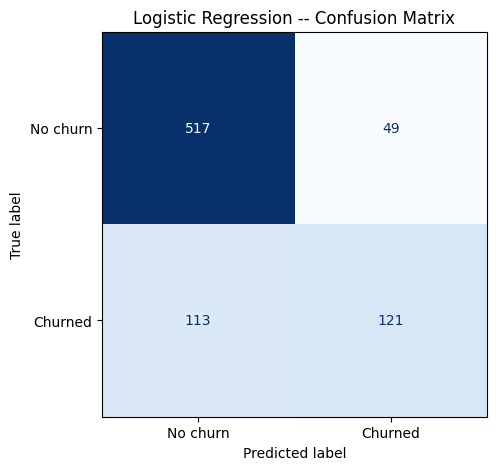

In [24]:

# TODO:
# 1. Create and fit a LogisticRegression model on X_train_scaled, y_train
# 2. Call evaluate_classifier(...) to see its performance

# Create the Logistic Regression model.
# max_iter=2000 gives the model enough iterations to converge.
log_reg = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

# Train the model using the scaled training data.
log_reg.fit(
    X_train_scaled,
    y_train
)

# Evaluate the trained model using unseen test data.
log_reg_results = evaluate_classifier(
    log_reg,
    X_test_scaled,
    y_test,
    "Logistic Regression"
)


### 🔍 Bonus insight: interpreting Logistic Regression coefficients

Unlike tree-based models, Logistic Regression gives you a **coefficient**
per feature — its sign tells you the *direction* of the relationship
(positive = pushes toward churn, negative = pushes toward staying), and
its magnitude (on **scaled** features, so magnitudes are comparable)
gives a rough sense of strength.


,Feature,Coefficient,Absolute_Coefficient
13,engagement_level,-0.866746,0.866746
14,satisfaction_rating,-0.839452,0.839452
16,subscription_plan_Premium,-0.559579,0.559579
15,subscription_plan_Family,-0.517965,0.517965
17,subscription_plan_Standard,-0.451477,0.451477
12,watched_trending_content,-0.387791,0.387791
9,auto_renew_enabled,-0.209374,0.209374
1,customer_tenure_months,-0.208644,0.208644
2,avg_watch_hours_per_week,-0.129104,0.129104
21,payment_method_Debit Card,0.075043,0.075043


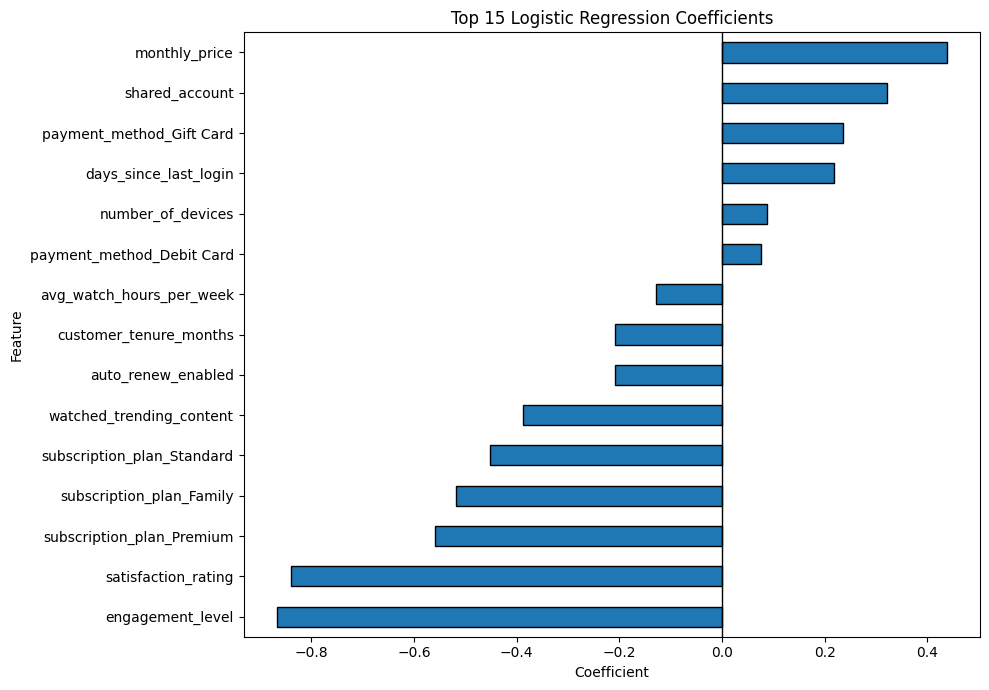

In [25]:

# TODO: Build a dataframe of feature names and log_reg.coef_[0], sort by
# absolute value, and plot the top 15 as a horizontal bar chart.
# Hint: log_reg.coef_[0] is a 1D array in the same order as X.columns

# your code here
# Create a dataframe containing each feature and its coefficient.
coefficient_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
})

# Calculate the absolute coefficient value.
# This allows us to identify the strongest coefficients regardless
# of whether they are positive or negative.
coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

# Select the 15 features with the largest absolute coefficients.
top_15_coefficients = (
    coefficient_df
    .sort_values(
        by="Absolute_Coefficient",
        ascending=False
    )
    .head(15)
)

# Sort by the actual coefficient value so the horizontal
# bar chart is easier to read.
top_15_coefficients = top_15_coefficients.sort_values(
    by="Coefficient"
)

# Display the coefficient table.
display(top_15_coefficients)

# Plot the top 15 coefficients.
ax = top_15_coefficients.plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    figsize=(10, 7),
    legend=False,
    edgecolor="black"
)

# Add a vertical line at zero to separate positive
# and negative coefficients.
ax.axvline(
    x=0,
    color="black",
    linewidth=1
)

ax.set_title("Top 15 Logistic Regression Coefficients")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()



## 9. Model 2 — K-Nearest Neighbors (KNN)

### 📝 Your task

**Part A — Choose K.** Loop over a range of K values (try `range(3, 32, 2)`),
train a `KNeighborsClassifier` on `X_train_scaled`/`y_train` for each,
and record the **test F1-score** (not just accuracy — remember, our
target is imbalanced, so accuracy alone can be misleading!). Store your
results in a dataframe and plot F1-score vs. K.

💡 **Hint:** you already have `f1_score` imported from Section 1's setup cell.


,K,F1_Score,Accuracy
0,3,0.468193,0.73875
1,5,0.442623,0.74500
2,7,0.420749,0.74875
3,9,0.417647,0.75250
4,11,0.398792,0.75125
5,13,0.401216,0.75375
6,15,0.377358,0.75250
7,17,0.361905,0.74875
8,19,0.340984,0.74875
9,21,0.306122,0.74500


Best K based on F1-score: 3


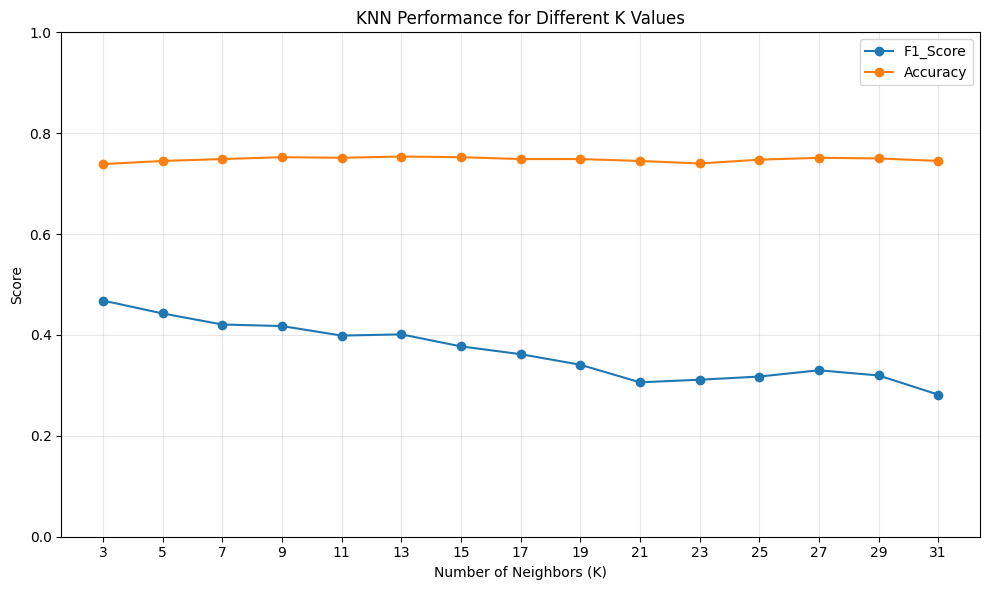

In [26]:

# TODO Part A:
# Loop over k_values = range(3, 32, 2). For each K:
#   - train a KNeighborsClassifier(n_neighbors=k) on X_train_scaled, y_train
#   - predict on X_test_scaled
#   - record both f1_score and accuracy_score in a list of dicts
# Then build a dataframe `k_df` and plot F1-score (and accuracy) vs. K

k_values = list(range(3, 32, 2))

# This list will store the performance of every K value.
k_results = []

# Train and evaluate one KNN model for each K value.
for k in k_values:

    # Create the KNN model.
    knn_candidate = KNeighborsClassifier(
        n_neighbors=k
    )

    # Train the model using the scaled training data.
    knn_candidate.fit(
        X_train_scaled,
        y_train
    )

    # Predict churn classes for the test data.
    y_pred = knn_candidate.predict(
        X_test_scaled
    )

    # Calculate the evaluation metrics.
    current_f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    current_accuracy = accuracy_score(
        y_test,
        y_pred
    )

    # Store the K value and its results.
    k_results.append({
        "K": k,
        "F1_Score": current_f1,
        "Accuracy": current_accuracy
    })


# Convert the list of dictionaries into a DataFrame.
k_df = pd.DataFrame(k_results)

# Display all results.
display(k_df)


# Find the K value with the highest F1-score.
best_k = int(
    k_df.loc[
        k_df["F1_Score"].idxmax(),
        "K"
    ]
)

print("Best K based on F1-score:", best_k)


# Plot F1-score and accuracy against K.
ax = k_df.plot(
    x="K",
    y=[
        "F1_Score",
        "Accuracy"
    ],
    kind="line",
    marker="o",
    figsize=(10, 6)
)

ax.set_title("KNN Performance for Different K Values")
ax.set_xlabel("Number of Neighbors (K)")
ax.set_ylabel("Score")
ax.set_xticks(k_values)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



**Part B — Train the final KNN.** Based on your plot above, pick the K
that gives the best **F1-score** (not necessarily the best accuracy!),
store it in `best_k`, train the final model, and evaluate it with
`evaluate_classifier(...)`.


Best K based on F1-score: 3
===== KNN (K=3) =====
Accuracy:  0.739
Precision: 0.579
Recall:    0.393
F1-score:  0.468
ROC-AUC:   0.707

              precision    recall  f1-score   support

    No churn       0.78      0.88      0.83       566
     Churned       0.58      0.39      0.47       234

    accuracy                           0.74       800
   macro avg       0.68      0.64      0.65       800
weighted avg       0.72      0.74      0.72       800



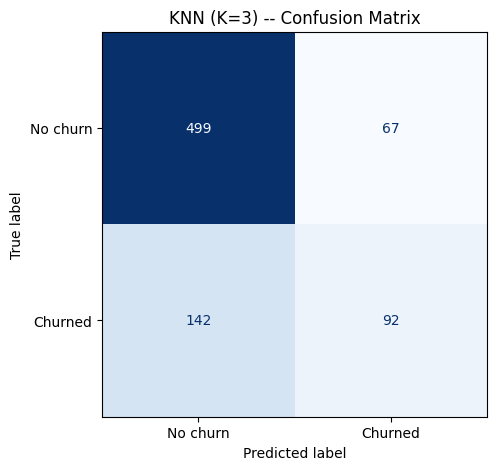

In [27]:

# TODO Part B:
# 1. Find the K in k_df with the highest f1_score -> store as `best_k`
#    Hint: k_df.loc[k_df["f1_score"].idxmax(), "K"]
# 2. Train a final KNeighborsClassifier with that K
# 3. Call evaluate_classifier(...)
# Use the correct F1-score column name from k_df.
# This supports both "f1_score" and "F1_Score".
f1_column = (
    "f1_score"
    if "f1_score" in k_df.columns
    else "F1_Score"
)

# Find the K value having the highest F1-score.
best_k = int(
    k_df.loc[
        k_df[f1_column].idxmax(),
        "K"
    ]
)

print("Best K based on F1-score:", best_k)

# Create the final KNN model using the best K.
knn_model = KNeighborsClassifier(
    n_neighbors=best_k
)

# Train the final model using scaled training data.
knn_model.fit(
    X_train_scaled,
    y_train
)

# Evaluate the final KNN model on the test data.
knn_results = evaluate_classifier(
    knn_model,
    X_test_scaled,
    y_test,
    f"KNN (K={best_k})"
)


### 🤔 Something to notice

Compare the **accuracy** curve to the **F1-score** curve you just plotted.
Do they agree on the best K? If not — why might a larger K look fine on
accuracy but get worse on F1, specifically on an imbalanced target like
this one? (Hint: think back to Session 5's discussion of what happens to
KNN predictions as K grows very large.)



## 10. Model 3 — Random Forest

### 📝 Your task

1. Create a `RandomForestClassifier` (`n_estimators=300`, `max_depth=8`,
   `min_samples_leaf=5`, `random_state=RANDOM_STATE`) and fit it on the
   **unscaled** `X_train`, `y_train` (remember: trees don't need scaling!).
2. Evaluate it with `evaluate_classifier(model, X_test, y_test, "Random Forest")`
   — note you pass the **unscaled** `X_test` here, not `X_test_scaled`.
3. Plot the top 15 features by importance (`model.feature_importances_`).


===== Random Forest =====
Accuracy:  0.775
Precision: 0.807
Recall:    0.303
F1-score:  0.441
ROC-AUC:   0.848

              precision    recall  f1-score   support

    No churn       0.77      0.97      0.86       566
     Churned       0.81      0.30      0.44       234

    accuracy                           0.78       800
   macro avg       0.79      0.64      0.65       800
weighted avg       0.78      0.78      0.74       800



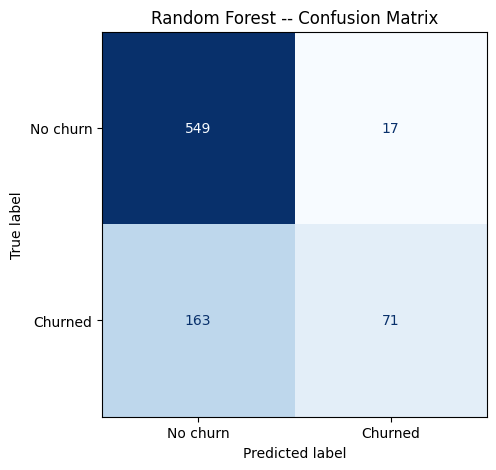

In [28]:

# TODO:
# 1. Create and fit a RandomForestClassifier on the UNSCALED X_train, y_train
# 2. Call evaluate_classifier(rf_model, X_test, y_test, "Random Forest")
#    (unscaled X_test here!)

# Create the Random Forest model.
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=RANDOM_STATE
)

# Train the model using the unscaled training data.
rf_model.fit(
    X_train,
    y_train
)

# Evaluate the model using the unscaled test data.
rf_results = evaluate_classifier(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)

Top 15 Random Forest feature importances:


,Feature Importance
satisfaction_rating,0.173858
engagement_level,0.133585
avg_watch_hours_per_week,0.123188
customer_tenure_months,0.118930
days_since_last_login,0.056194
monthly_price,0.052793
number_of_support_tickets,0.050959
avg_session_length_min,0.048701
watched_trending_content,0.038320
age,0.035911


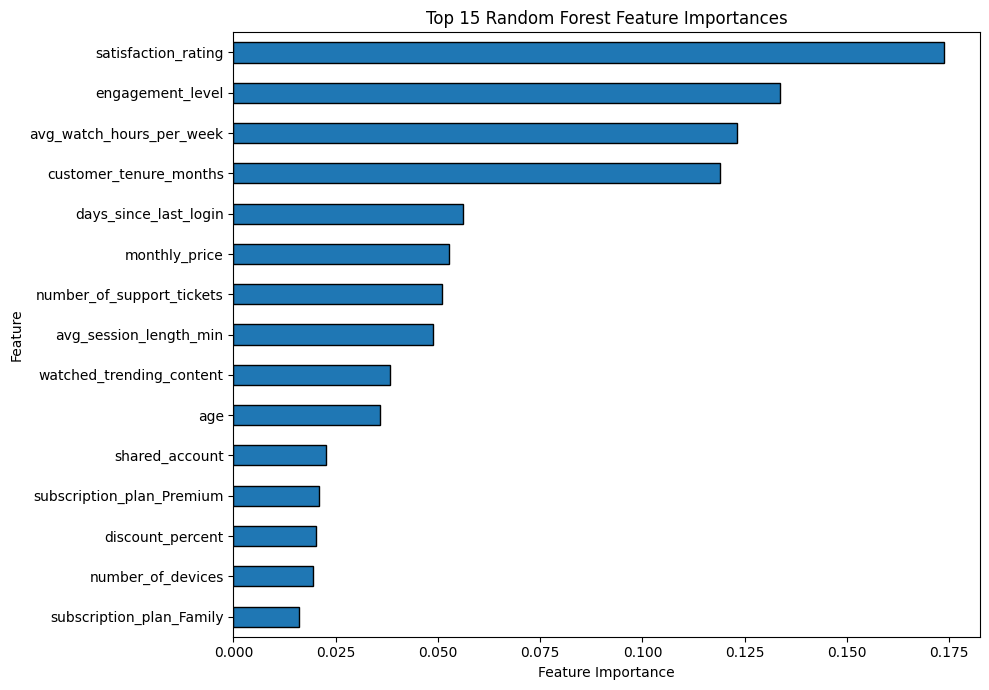

In [29]:

# TODO: Build a Series of rf_model.feature_importances_ indexed by X.columns,
# sort descending, and plot the top 15 as a horizontal bar chart.

# your code here

# Create a Series containing each feature and its importance score.
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns,
    name="Feature Importance"
)

# Sort all features from highest to lowest importance.
feature_importance = feature_importance.sort_values(
    ascending=False
)

# Select the 15 most important features.
top_15_features = feature_importance.head(15)

# Display the top 15 feature importance scores.
print("Top 15 Random Forest feature importances:")
display(top_15_features.to_frame())

# Reverse the order for the horizontal chart so that
# the most important feature appears at the top.
top_15_features.sort_values().plot(
    kind="barh",
    figsize=(10, 7),
    edgecolor="black"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



### 🤔 Cross-check

Do the Random Forest's top features roughly agree with the Logistic
Regression coefficients you plotted in Section 8? Which features does
your intuition from the EDA in Section 3 say *should* matter — and do
they show up here?



## 11. Model Comparison

### 📝 Your task

Every call to `evaluate_classifier(...)` above already appended a row to
the global `results_summary` list. Turn it into a clean comparison
dataframe (`comparison_df`), sorted by `roc_auc` descending, and display it.


In [30]:

# TODO: Build `comparison_df` from the `results_summary` list, sorted by
# roc_auc descending
# Hint: pd.DataFrame(results_summary).sort_values(...)

# Convert the list of model-result dictionaries into a DataFrame.
comparison_df = pd.DataFrame(results_summary)

# Use the ROC-AUC column name available in the DataFrame.
roc_auc_column = (
    "roc_auc"
    if "roc_auc" in comparison_df.columns
    else "ROC_AUC"
)

# Sort models from highest to lowest ROC-AUC.
comparison_df = (
    comparison_df
    .sort_values(
        by=roc_auc_column,
        ascending=False
    )
    .reset_index(drop=True)
)

# Display the final comparison table.
display(comparison_df)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest,0.77500,0.806818,0.303419,0.440994,0.848147
1,Logistic Regression,0.79750,0.711765,0.517094,0.599010,0.832027
2,KNN (K=3),0.73875,0.578616,0.393162,0.468193,0.706823



### 📝 Your task — ROC curves

Plot the ROC curve for all three models on the same axes (using the
`probabilities` each `evaluate_classifier(...)` call returned, saved
earlier as `lr_results`, `knn_results`, `rf_results`), along with the
diagonal "random guess" reference line.

💡 **Hint:** `roc_curve(y_test, probabilities)` returns `(fpr, tpr, thresholds)`.


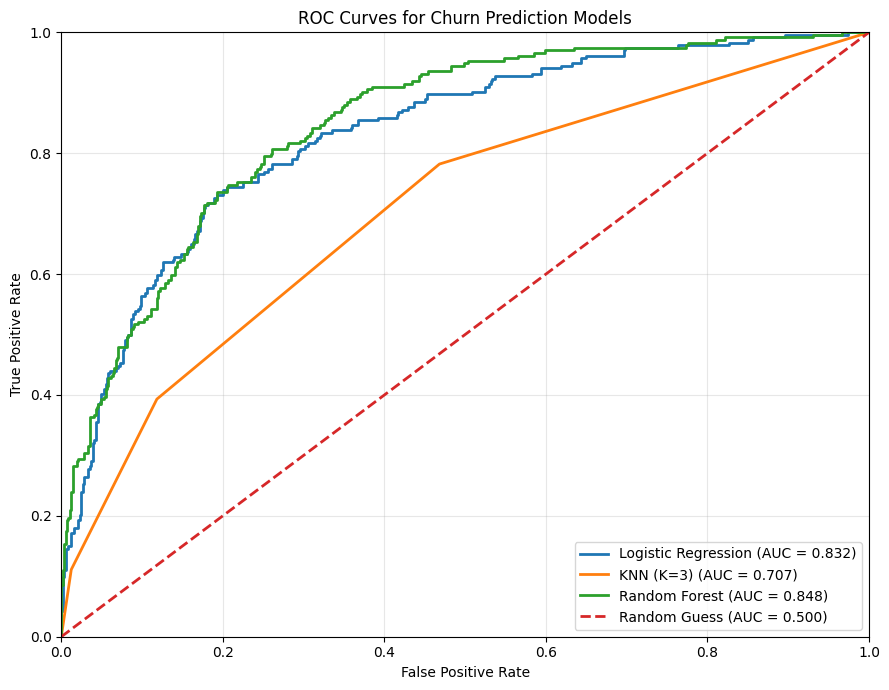

In [31]:

# TODO: Plot ROC curves for all 3 models on one chart, plus the diagonal
# random-guess reference line.
# Hint: for each model, fpr, tpr, _ = roc_curve(y_test, results["probabilities"])

# your code here

# Store each model's evaluation results in one dictionary.
model_results = {
    "Logistic Regression": log_reg_results,
    f"KNN (K={best_k})": knn_results,
    "Random Forest": rf_results
}

# Create the ROC curve figure.
plt.figure(figsize=(9, 7))

# Calculate and plot the ROC curve for each model.
for model_name, results in model_results.items():

    # Retrieve the predicted probability of churn.
    probabilities = results["probabilities"]

    # Calculate false-positive and true-positive rates.
    fpr, tpr, thresholds = roc_curve(
        y_test,
        probabilities
    )

    # Calculate the area under the ROC curve.
    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    # Plot the model's ROC curve.
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

# Add the random-guess reference line.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Guess (AUC = 0.500)"
)

# Add labels and formatting.
plt.title("ROC Curves for Churn Prediction Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 12. Business Recommendation

You've now built and evaluated three models. Time to think like a data
scientist presenting to StreamVibe's retention team, not just a student
running cells.

### ✍️ Write your recommendation (double-click to edit)

**1. Which model would you recommend StreamVibe actually deploy, and why?**
Consider accuracy, F1-score, and ROC-AUC together — not just whichever
number is highest.

I would recommend deploying **Logistic Regression as the initial model**.

Logistic Regression achieved an accuracy of approximately **79.8%**, an F1-score of **0.599**, and a ROC-AUC of **0.832**. Although Random Forest achieved the highest ROC-AUC at approximately **0.848**, its recall was only **0.303** and its F1-score was only **0.441**. This means Random Forest correctly identified high-risk customers with good precision, but missed many customers who actually churned.

Logistic Regression offered the best overall balance between accuracy, recall, F1-score, and ROC-AUC. It is also easier to explain to the retention team because its coefficients show how different customer characteristics affect churn risk. Therefore, it would be a safer and more understandable model for the first deployment. Later, StreamVibe could tune its probability threshold or improve the Random Forest model through hyperparameter tuning.

**2. StreamVibe's retention team can only afford to send a personalized discount offer to a limited number of customers each month. Would you prioritize a model with high precision, or high recall, for deciding who receives an offer? Explain the business trade-off in your own words.**

Because StreamVibe can only send personalized discount offers to a limited number of customers, I would prioritize **high precision**.

High precision means that when the model labels a customer as likely to churn, there is a greater chance that the customer is genuinely at risk. This reduces the number of discounts wasted on customers who would have stayed without an offer.

The trade-off is that prioritizing precision may reduce recall. This means some real churners may not be selected for an offer. However, when the campaign has a limited budget and limited capacity, it is better to focus on the customers with the highest predicted churn probabilities.

StreamVibe could rank customers by churn probability and send offers only to the highest-risk customers that fit within the monthly campaign budget.


**3. Based on your Logistic Regression coefficients (Section 8) and
Random Forest feature importances (Section 10), what are 2-3 concrete,
actionable things StreamVibe could do to reduce churn?**

**1. Create an early re-engagement campaign.**  
Customers with low watch hours, low engagement, or a high number of days since their last login should receive personalized content recommendations, reminders about unfinished shows, or emails highlighting new content related to their viewing history.

**2. Improve satisfaction and customer support.**  
Low satisfaction and repeated support tickets appear to be important churn signals. StreamVibe should identify unresolved complaints, improve response times, and contact customers shortly after a poor support experience to confirm that their issue has been resolved.

**3. Improve the value of subscription plans.**  
Monthly price and subscription plan information were important in the models. Instead of offering discounts to everyone, StreamVibe could offer high-risk customers a temporary discount, a lower-priced plan, a free upgrade, or a plan better matched to their viewing habits.



**4. Which features turned out to matter much less than you expected
going into this case study? Does that match what the dataset generator
intended to be "weak" or "noise" features?**

Features such as **device type, payment method, number of devices, age, and use of offline downloads** appeared to matter less than I initially expected.

These features describe the customer's general profile or how they access the service, but they do not directly show whether the customer is becoming dissatisfied or disengaged. Behavioural features such as satisfaction, engagement, watch hours, customer tenure, and days since the last login were much more useful.

This appears to match the dataset generator's intention for some variables to act as weak or noise features. Their inclusion makes the dataset more realistic because real business datasets usually contain some variables that provide little predictive value.



**5. If you deployed your chosen model and it flagged a real customer as "high churn risk," what would you want to see before fully trusting that prediction?**

Before fully trusting the prediction, I would first examine the customer's **predicted churn probability**, not only the final Yes/No classification. A customer with a predicted probability of 90% should be treated differently from one with a probability of 51%.

I would also review the main reasons behind the prediction, including:

- Recent watch hours and whether usage has been declining
- Days since the customer's last login
- Satisfaction rating
- Recent support tickets or unresolved complaints
- Subscription plan, monthly price, and discount history
- Whether the customer's information is complete and accurate

I would also want a local explanation, such as a SHAP explanation, showing which features pushed that individual customer's prediction toward high risk.

Finally, before relying on the system at scale, I would monitor false positives, compare predictions with actual churn outcomes, and check that the model is not unfairly targeting a particular age group, payment group, or customer category.



## 13. Bonus / Stretch Challenges (Optional)

Pick one or more of these to go further:

### Challenge A — Handle class imbalance directly
Retrain Logistic Regression and Random Forest with `class_weight="balanced"`.
Does precision/recall trade off differently? Does F1-score improve?

### Challenge B — Hyperparameter tuning
Use `GridSearchCV` (imported already if you add the import) to tune
`max_depth` and `min_samples_leaf` for the Random Forest, optimizing for
F1-score (`scoring="f1"`). Does the tuned model beat your Section 10 model
on the test set?

### Challenge C — Feature engineering
Create a new feature — for example, `watch_hours_per_dollar =
avg_watch_hours_per_week / monthly_price`, or a flag for "recently gone
quiet" (`days_since_last_login > 14`). Retrain your best model with the
new feature included. Did it help?

### Challenge D — Threshold tuning
By default, `model.predict()` uses a 0.5 probability threshold. Using
`model.predict_proba()` directly, try a lower threshold (e.g., 0.3) for
your best model to catch more churners (higher recall), and see how much
precision you give up in exchange. Which threshold would you recommend to
the business, and why?


In [ ]:

# Bonus challenge -- your experimentation code here




---

## 🎉 Capstone Wrap-Up

You just built a complete, end-to-end machine learning pipeline: loading
real-world-messy data, cleaning it, encoding it, training three
genuinely different kinds of models (a linear model, a distance-based
model, and a tree ensemble), evaluating them fairly on the same test set,
and translating the results into a business recommendation. That's the
whole job, start to finish — nice work! 🚀
